# **Tox21 Toxicity Classification ML Pipeline**

**Author — Marco La Rosa**

---

## Overview

This project presents a machine learning pipeline for **toxicity prediction** using the Tox21 dataset. The objective is to classify chemical compounds as **toxic (active)** or **non-toxic (inactive)** based on their interaction with biological targets.

The pipeline spans from **data preprocessing and feature engineering** to **model training, evaluation, and comparison**, with a particular focus on handling **class imbalance** and **feature representation**.

The study evaluates and compares three feature types:

* Molecular Descriptors
* Morgan Fingerprints
* Combined Features (Descriptors + Fingerprints)

And three classification algorithms:

* Logistic Regression
* Support Vector Machines
* Random Forest

---

## Background

Toxicity in the Tox21 dataset is defined in terms of **biological activity**, i.e., whether a compound activates a specific receptor or signaling pathway.

In this project, the focus is on:

> **NR-AhR (Aryl Hydrocarbon Receptor)** — a transcription factor involved in xenobiotic metabolism and toxicity pathways.

Compounds are labeled as:

* **1 (Toxic / Active)** → activates the receptor
* **0 (Non-toxic / Inactive)** → does not activate the receptor

---

## Dataset Overview

**Source — Tox21 Dataset**

* Target endpoints: 12 multiple bioassays
* Samples: **7,831 molecules** described by "mol_id" and "smiles"

## **0. Initial setup**

In [9]:
# importing libraries

# standard libraries
from pathlib import Path
import joblib
import warnings

# data handling
import pandas as pd
import numpy as np

# chemistry
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, rdFingerprintGenerator

# plots
import matplotlib.pyplot as plt
import seaborn as sns

# ML - preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold, SelectKBest, RFE

# ML - model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV

# ML - models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# ML - metrics
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    matthews_corrcoef,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
    auc
)

In [10]:
# function to save plots in directory

PLOT_DIR = Path("results/plots")

def save_plot(name, path=PLOT_DIR):
    path.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path / f"{name}.png")

In [11]:
# colormap for matplotlib

cmap = "viridis"

In [12]:
# seed for reproducibility of data

seed = 23

In [13]:
# reading dataset

!mkdir -p data/raw && \
wget -O data/raw/tox21.csv.gz https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz

tox21_df = pd.read_csv("data/raw/tox21.csv.gz")

--2026-05-02 11:54:57--  https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/tox21.csv.gz
Caricato certificato CA "/etc/ssl/certs/ca-certificates.crt"

Risoluzione di deepchemdata.s3-us-west-1.amazonaws.com (deepchemdata.s3-us-west-1.amazonaws.com)... 52.219.121.114, 52.219.220.66, 16.15.0.122, ...
Connessione a deepchemdata.s3-us-west-1.amazonaws.com (deepchemdata.s3-us-west-1.amazonaws.com)|52.219.121.114|:443... connesso.
Richiesta HTTP inviata, in attesa di risposta... 200 OK
Lunghezza: 122925 (120K) [application/x-gzip]
Salvataggio in: ‘data/raw/tox21.csv.gz’

data/raw/tox21.csv. 100%[===================>] 120,04K   333KB/s    in 0,4s    

2026-05-02 11:54:59 (333 KB/s) - ‘data/raw/tox21.csv.gz’ salvato [122925/122925]



## **1. Dataset preparation**

In [14]:
tox21_df.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [15]:
n_mol = tox21_df.shape[0]
n_col = tox21_df.shape[1]

print(f"Number of samples (molecules): {n_mol}")
print(f"Number of columns: {n_col}")

Number of samples (molecules): 7831
Number of columns: 14


We have 7831 samples. For each molecule we have the labels of 12 different toxicity bioassays, the mol_id and the SMILES of the molecule

First, we have to filter invalid SMILES:

In [16]:
# filtering molecules not processed by MolFromSmiles function

df = tox21_df[tox21_df["smiles"].apply(lambda x: Chem.MolFromSmiles(x) is not None)].reset_index(drop=True)

[11:54:59] WARNING: not removing hydrogen atom without neighbors
[11:54:59] Explicit valence for atom # 8 Al, 6, is greater than permitted
[11:54:59] Explicit valence for atom # 3 Al, 6, is greater than permitted
[11:54:59] Explicit valence for atom # 4 Al, 6, is greater than permitted
[11:54:59] Explicit valence for atom # 4 Al, 6, is greater than permitted
[11:54:59] Explicit valence for atom # 9 Al, 6, is greater than permitted
[11:54:59] Explicit valence for atom # 5 Al, 6, is greater than permitted
[11:54:59] Explicit valence for atom # 16 Al, 6, is greater than permitted
[11:54:59] Explicit valence for atom # 20 Al, 6, is greater than permitted


In [17]:
n_mol_processed = df.shape[0]
print(f"Deleted {n_mol - n_mol_processed} samples")
print(f"Number of samples: {n_mol_processed}")

Deleted 8 samples
Number of samples: 7823


We filtered 8 molecules with invalid SMILES

Let's see how many repeated molecules are in the dataset:

In [18]:
df["mol_id"].nunique()

7823

Actually, all molecules are different.

Example of 3 random molecules from the dataset:


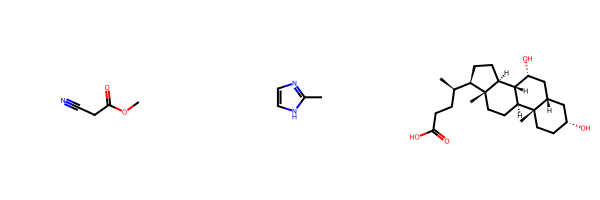

In [19]:
print("Example of 3 random molecules from the dataset:")

mols = [Chem.MolFromSmiles(s) for s in df["smiles"].sample(n=3)]
Draw.MolsToGridImage(mols)

In [20]:
df.columns

Index(['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD',
       'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53',
       'mol_id', 'smiles'],
      dtype='str')

In [21]:
targets = df.columns[:-2]

print("The bioassays are: ")
for i in range(len(targets)):
  print(f"{i+1}. {targets[i]}")

The bioassays are: 
1. NR-AR
2. NR-AR-LBD
3. NR-AhR
4. NR-Aromatase
5. NR-ER
6. NR-ER-LBD
7. NR-PPAR-gamma
8. SR-ARE
9. SR-ATAD5
10. SR-HSE
11. SR-MMP
12. SR-p53


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7823 entries, 0 to 7822
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   NR-AR          7258 non-null   float64
 1   NR-AR-LBD      6751 non-null   float64
 2   NR-AhR         6542 non-null   float64
 3   NR-Aromatase   5815 non-null   float64
 4   NR-ER          6186 non-null   float64
 5   NR-ER-LBD      6948 non-null   float64
 6   NR-PPAR-gamma  6443 non-null   float64
 7   SR-ARE         5825 non-null   float64
 8   SR-ATAD5       7065 non-null   float64
 9   SR-HSE         6460 non-null   float64
 10  SR-MMP         5804 non-null   float64
 11  SR-p53         6767 non-null   float64
 12  mol_id         7823 non-null   str    
 13  smiles         7823 non-null   str    
dtypes: float64(12), str(2)
memory usage: 855.8 KB


## **2. Exploratory Data Analysis**

### **2.1 Checking missing values**

Let's see how many missing values there are for each target:

In [23]:
df.isnull().sum()

NR-AR             565
NR-AR-LBD        1072
NR-AhR           1281
NR-Aromatase     2008
NR-ER            1637
NR-ER-LBD         875
NR-PPAR-gamma    1380
SR-ARE           1998
SR-ATAD5          758
SR-HSE           1363
SR-MMP           2019
SR-p53           1056
mol_id              0
smiles              0
dtype: int64

Let's also see briefly class distribution:

In [24]:
for target in targets:
    data_counts = df.groupby(target).size()
    print(data_counts)

NR-AR
0.0    6950
1.0     308
dtype: int64
NR-AR-LBD
0.0    6514
1.0     237
dtype: int64
NR-AhR
0.0    5774
1.0     768
dtype: int64
NR-Aromatase
0.0    5515
1.0     300
dtype: int64
NR-ER
0.0    5395
1.0     791
dtype: int64
NR-ER-LBD
0.0    6599
1.0     349
dtype: int64
NR-PPAR-gamma
0.0    6257
1.0     186
dtype: int64
SR-ARE
0.0    4883
1.0     942
dtype: int64
SR-ATAD5
0.0    6801
1.0     264
dtype: int64
SR-HSE
0.0    6088
1.0     372
dtype: int64
SR-MMP
0.0    4886
1.0     918
dtype: int64
SR-p53
0.0    6344
1.0     423
dtype: int64


We know that the dataset is skewed between the two classes and is missing many values. Let's visualize it better:

In [25]:
# summary of dataset

summary = []

for target in targets:
    not_toxic = (df[target] == 0).sum()
    toxic = (df[target] == 1).sum()
    nan = (df[target]).isnull().sum()

    total = not_toxic + toxic + nan
    valid_total = not_toxic + toxic

    summary.append({
        "Target": target,
        "Not Toxic": not_toxic,
        "Toxic": toxic,
        "Missing": nan,
        "Toxic % (on valid)": (toxic / valid_total) * 100,
        "Not Toxic % (on valid)": (not_toxic / valid_total) * 100,
        "Missing % (on total)": (nan / total * 100)
        })

summary_df = pd.DataFrame(summary)

In [26]:
counts_df = summary_df[["Target", "Not Toxic", "Toxic", "Missing"]]
print(counts_df)

           Target  Not Toxic  Toxic  Missing
0           NR-AR       6950    308      565
1       NR-AR-LBD       6514    237     1072
2          NR-AhR       5774    768     1281
3    NR-Aromatase       5515    300     2008
4           NR-ER       5395    791     1637
5       NR-ER-LBD       6599    349      875
6   NR-PPAR-gamma       6257    186     1380
7          SR-ARE       4883    942     1998
8        SR-ATAD5       6801    264      758
9          SR-HSE       6088    372     1363
10         SR-MMP       4886    918     2019
11         SR-p53       6344    423     1056


In [27]:
# printing missing values

missing_df = summary_df[["Target", "Missing % (on total)"]]

print(
    missing_df
    .sort_values(by="Missing % (on total)", ascending=False)
    .to_string(formatters={
        "Missing % (on total)": lambda x: f"{x:.2f}"
    })
)

           Target Missing % (on total)
10         SR-MMP                25.81
3    NR-Aromatase                25.67
7          SR-ARE                25.54
4           NR-ER                20.93
6   NR-PPAR-gamma                17.64
9          SR-HSE                17.42
2          NR-AhR                16.37
1       NR-AR-LBD                13.70
11         SR-p53                13.50
5       NR-ER-LBD                11.18
8        SR-ATAD5                 9.69
0           NR-AR                 7.22


The dataset contains a significant amount of missing values across different targets

### **2.2 Checking class distribution**

In [28]:
# printing class distribution between toxic and not toxic

balance_df = summary_df[["Target", "Toxic % (on valid)", "Not Toxic % (on valid)"]]

print(
    balance_df
    .sort_values(by="Toxic % (on valid)", ascending=False)
    .to_string(formatters={
        "Toxic % (on valid)": lambda x: f"{x:.2f}%",
        "Not Toxic % (on valid)": lambda x: f"{x:.2f}%",
    })
)

           Target Toxic % (on valid) Not Toxic % (on valid)
7          SR-ARE             16.17%                 83.83%
10         SR-MMP             15.82%                 84.18%
4           NR-ER             12.79%                 87.21%
2          NR-AhR             11.74%                 88.26%
11         SR-p53              6.25%                 93.75%
9          SR-HSE              5.76%                 94.24%
3    NR-Aromatase              5.16%                 94.84%
5       NR-ER-LBD              5.02%                 94.98%
0           NR-AR              4.24%                 95.76%
8        SR-ATAD5              3.74%                 96.26%
1       NR-AR-LBD              3.51%                 96.49%
6   NR-PPAR-gamma              2.89%                 97.11%


We can visualize the skewness between the two classes for each target using a bar plot:

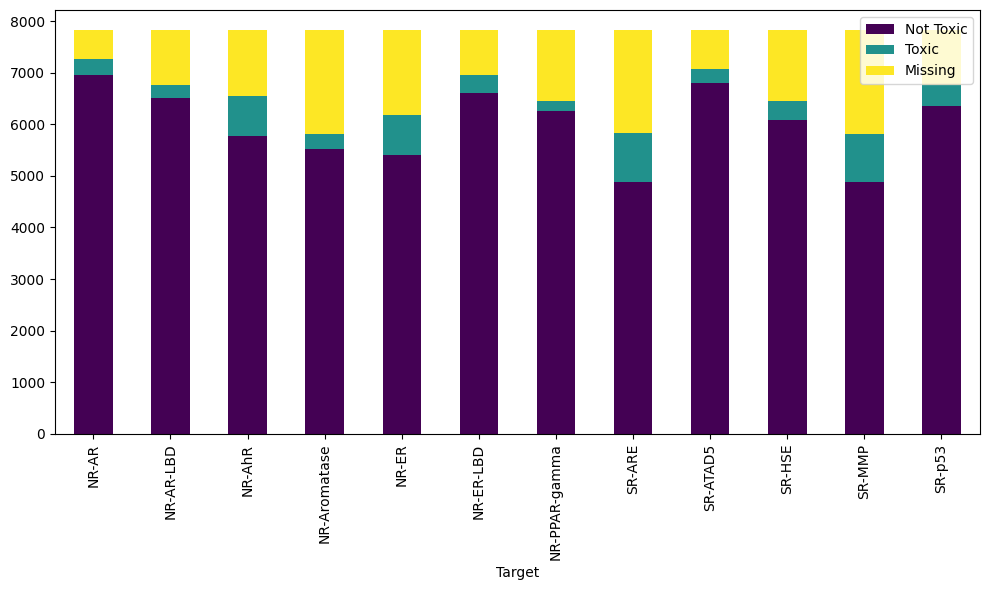

In [29]:
# visualizing classes distributions

ax = counts_df.set_index("Target").plot.bar(stacked=True, figsize=(10, 6), cmap=cmap)
fig = ax.get_figure()
save_plot("class-distribution")
plt.show()

### **2.3 Choosing our target endpoint**

The **NR-AhR** target was selected as a compromise between data availability and class distribution:

- It presents a **moderate amount of missing values (~16%)**, allowing us to retain a sufficient number of samples
- It has a **relatively higher proportion of positive (toxic) samples (~11.7%)** compared to other targets, which are often more severely imbalanced

This choice provides a more stable and informative setting for model training, avoiding both excessive data loss and extreme class imbalance.

We are dropping molecules with missing output of the NR-AhR assay:

In [30]:
# using only NR-AhR as our target

NR_AhR_df = df[["NR-AhR", "smiles"]].dropna().reset_index(drop=True)
print(NR_AhR_df)

      NR-AhR                                             smiles
0        1.0                       CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1        0.0                          CCN1C(=O)NC(c2ccccc2)C1=O
2        0.0                    CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
3        0.0                          CC(O)(P(=O)(O)O)P(=O)(O)O
4        0.0               CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C
...      ...                                                ...
6537     0.0                     CCCn1c(=O)[nH]c(=O)c2[nH]cnc21
6538     0.0                 CCCNCC(O)COc1ccccc1C(=O)CCc1ccccc1
6539     0.0  CC(=O)[C@H]1CC[C@H]2[C@@H]3CCC4=CC(=O)CC[C@]4(...
6540     0.0  C[C@]12CC[C@H]3[C@@H](CCC4=CC(=O)CC[C@@]43C)[C...
6541     0.0  C[C@]12CC[C@@H]3c4ccc(O)cc4CC[C@H]3[C@@H]1CC[C...

[6542 rows x 2 columns]


In [31]:
print(f"Number of molecules: {NR_AhR_df.shape[0]}")

Number of molecules: 6542


We're using 6542 molecules out of the 7831 molecules of the entire dataset.

In [32]:
y = NR_AhR_df["NR-AhR"]
print(y)

0       1.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
6537    0.0
6538    0.0
6539    0.0
6540    0.0
6541    0.0
Name: NR-AhR, Length: 6542, dtype: float64


## **3. Feature engineering**

### **3.1 Molecular descriptors**

#### **3.1.1 Feature Extraction**

We're using physicochemical properties as features of the molecules, extracted via the *Descriptors* tool of rdkit library:

In [33]:
# extracting molecular descriptors

desc_names = [x[0] for x in Descriptors.descList]
desc_funcs = [x[1] for x in Descriptors.descList]

all_desc_values = []

for smiles in NR_AhR_df["smiles"]:
    mol = Chem.MolFromSmiles(smiles)
    desc_values = [f(mol) for f in desc_funcs]
    all_desc_values.append(desc_values)

desc_df = pd.DataFrame(all_desc_values, columns=desc_names)
desc_df.head()

[11:55:00] WARNING: not removing hydrogen atom without neighbors
[11:55:00] WARNING: not removing hydrogen atom without neighbors


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,11.107593,11.107593,0.073011,-3.723219,0.900283,11.875000,258.324,248.244,258.013284,86,...,0,1,0,0,0,1,0,0,0,0
1,11.790004,11.790004,0.172500,-0.515139,0.738013,20.600000,204.229,192.133,204.089878,78,...,0,0,0,0,0,0,0,0,0,1
2,12.570517,12.570517,0.042633,-0.042633,0.822261,12.500000,276.424,248.200,276.220164,112,...,0,0,0,0,0,0,0,0,0,0
3,10.251875,10.251875,0.383488,-5.197724,0.365583,15.090909,206.027,197.963,205.974526,68,...,0,0,0,0,0,0,0,0,0,0
4,5.538351,5.538351,0.306911,-0.365434,0.497486,14.700000,290.444,256.172,290.245710,122,...,0,0,0,0,0,0,0,0,0,0


In [34]:
print(f"Number of features: {desc_df.shape[1]}")

Number of features: 217


We delete features that contains infinite values. These are not processed by scikit-learn tools.

In [35]:
# delete infinite features

mask = np.isfinite(desc_df).all()

desc_df_clean = desc_df.loc[:, mask]

In [36]:
print(f"Deleted {desc_df.shape[1] - desc_df_clean.shape[1]} features")
print(f"Number of features: {desc_df_clean.shape[1]}")

Deleted 12 features
Number of features: 205


In [37]:
desc_df_clean.columns

Index(['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex',
       'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt',
       'NumValenceElectrons',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='str', length=205)

#### **3.1.2 Exploratory Data Analysis**

Comparing feature distributions between toxic and non-toxic cases helps identify variables with the strongest class separation. However, analyzing all features directly would introduce unnecessary noise and computational overhead.

To address this, we first rank features using Mutual Information (MI) and select the top 10 most informative ones. We then visualize their distributions using violin plots to better assess their discriminative behavior across the two classes.

In [38]:
# top 10 features based on MI

mi_scores = mutual_info_classif(desc_df_clean, y, random_state=seed)

mi_df = pd.DataFrame({
    "feature": desc_df_clean.columns,
    "mi_score": mi_scores
}).sort_values(by="mi_score", ascending=False)

top10_features = mi_df.head(10)["feature"].tolist()

print(mi_df.head(10))

              feature  mi_score
50          SMR_VSA10  0.076248
56           SMR_VSA7  0.071567
93       FractionCSP3  0.059922
67         SlogP_VSA6  0.053694
103  NumAromaticRings  0.052198
17               Chi0  0.049013
89        VSA_EState6  0.048322
69         SlogP_VSA8  0.045902
71               TPSA  0.045673
29      HallKierAlpha  0.044304


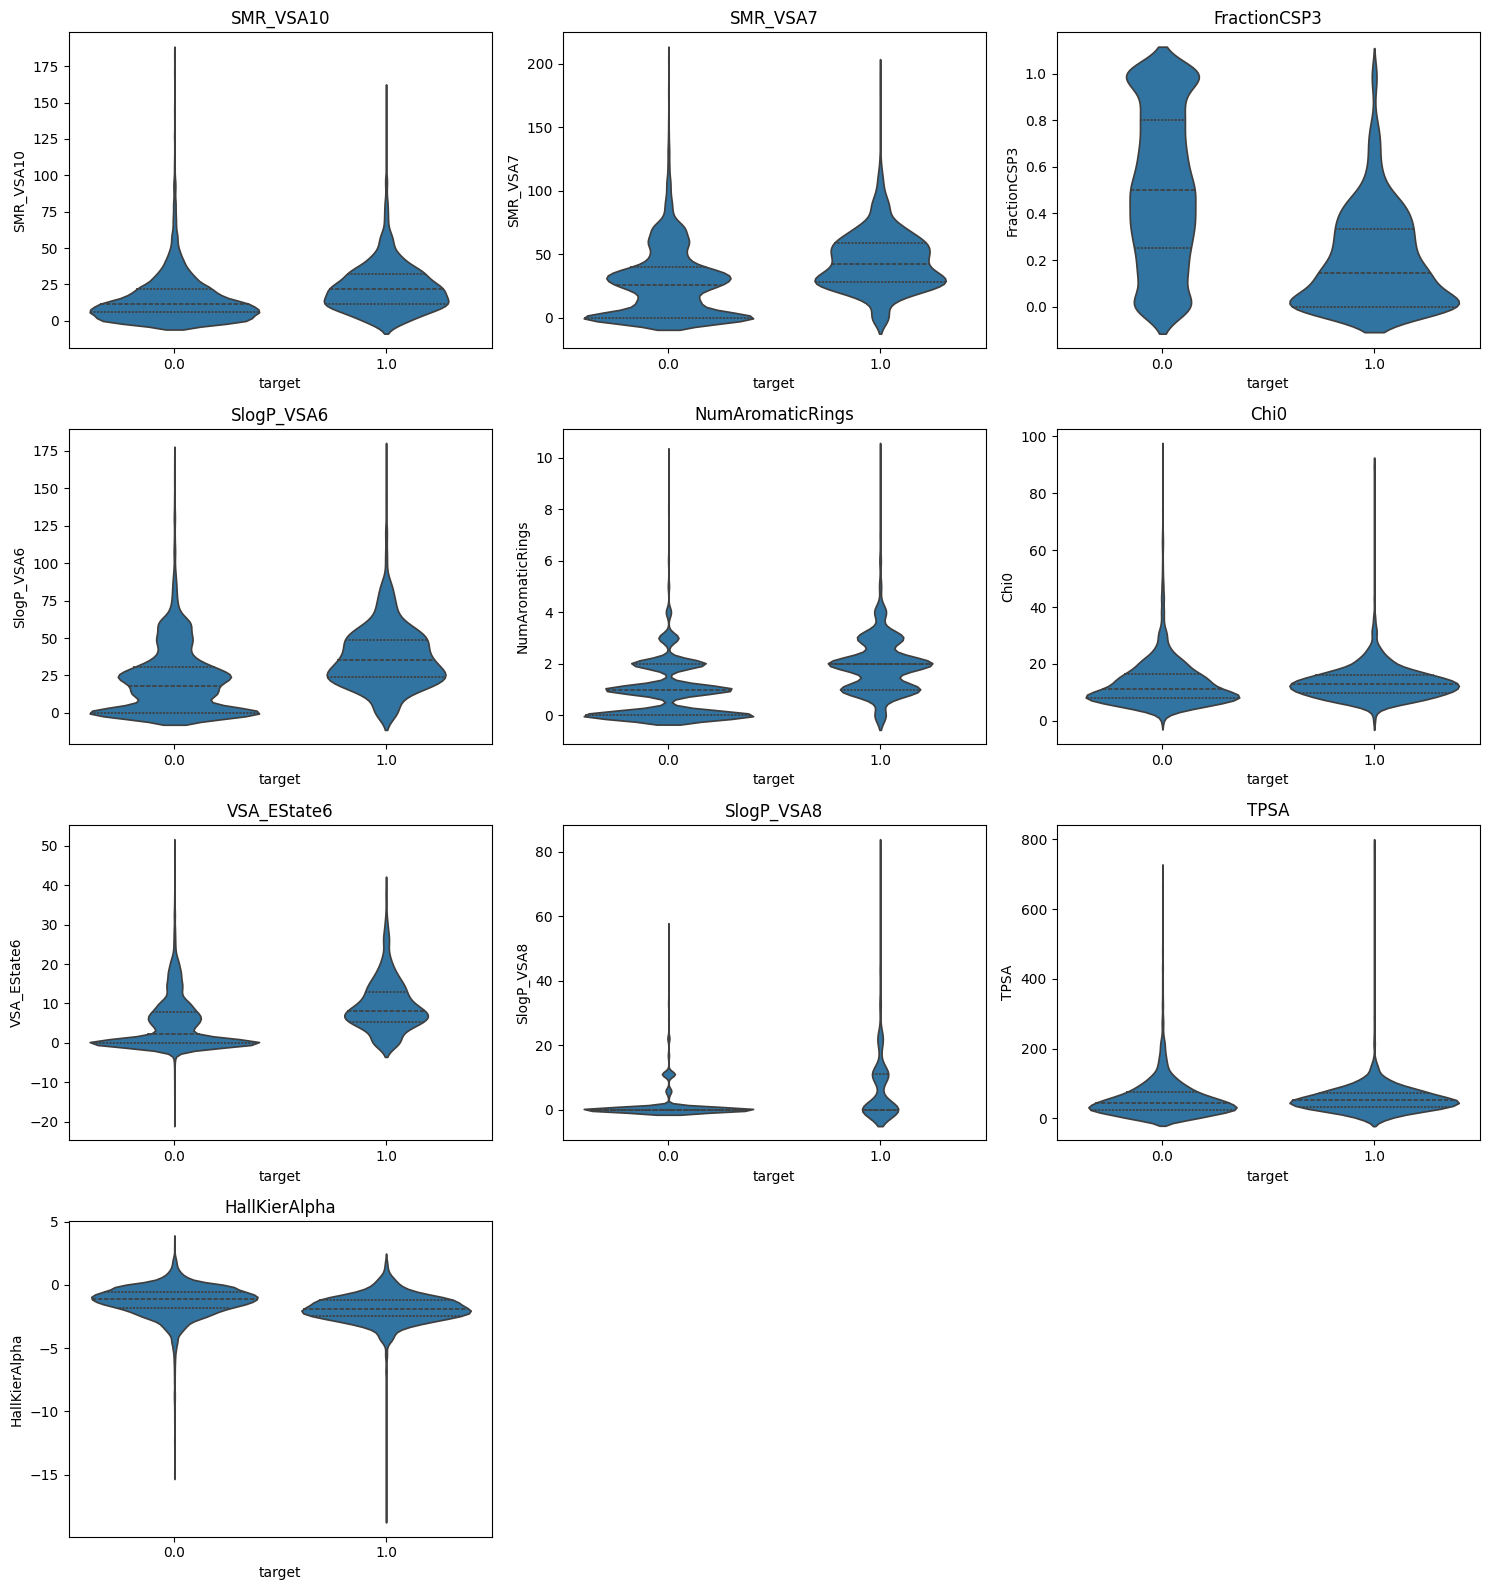

In [39]:
# visualizing feature distribution grouped by class of top 10 features based on MI

X_top10 = desc_df_clean[top10_features].copy()
X_top10["target"] = y.values

n_cols = 3
n_rows = (len(top10_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(top10_features):
    sns.violinplot(
        cmap=cmap,
        data=X_top10,
        x="target",
        y=feature,
        ax=axes[i],
        inner="quartile"
    )
    axes[i].set_title(feature)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
save_plot("top10-feature-distro-violin-plot")
plt.show()

It is important to note that these visualizations are used for exploratory analysis only and should not be used for feature selection, since they are computed on the entire dataset. Doing so would introduce data leakage and lead to overly optimistic performance estimates.

A Pearson correlation analysis is used to identify strong linear relationships, multicollinearity, and redundancy among features.

Given the high number of descriptors (>200), a full heatmap would be difficult to interpret and visually cluttered. Instead, we focus on reporting the most highly correlated feature pairs, which provides a clearer and more actionable view of redundancy in the feature space while maintaining interpretability.

In [40]:
# printing higly correlated pairs of features

threshold = 0.95

corr = desc_df.corr()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

corr_pairs = (
    upper.stack()
    .reset_index()
)

corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

high_corr_pairs = corr_pairs[
    corr_pairs["Correlation"].abs() > threshold
]

high_corr_pairs = high_corr_pairs.sort_values(
    by="Correlation",
    ascending=False
)

print(f"Highly correlated feature pairs (Pearson Coefficient > {threshold}):")
print("="*30)
for a, b, val in high_corr_pairs.values:
    print(f"{a} - {b}: {val:.3f}")

Highly correlated feature pairs (Pearson Coefficient > 0.95):
MaxAbsEStateIndex - MaxEStateIndex: 1.000
NumAmideBonds - fr_amide: 1.000
fr_Ar_NH - fr_Nhpyrrole: 1.000
MolWt - ExactMolWt: 1.000
Kappa2 - Phi: 1.000
Chi1 - HeavyAtomCount: 0.999
MolWt - HeavyAtomMolWt: 0.998
HeavyAtomMolWt - ExactMolWt: 0.998
NumAromaticCarbocycles - fr_benzene: 0.998
Chi0 - HeavyAtomCount: 0.997
NumValenceElectrons - Chi0: 0.997
fr_COO - fr_COO2: 0.996
NumValenceElectrons - HeavyAtomCount: 0.995
Chi0 - Chi1: 0.994
LabuteASA - HeavyAtomCount: 0.994
Chi0n - Chi1n: 0.993
Chi1 - LabuteASA: 0.993
NumValenceElectrons - Chi1: 0.993
Chi0v - LabuteASA: 0.992
Chi0 - LabuteASA: 0.992
NumValenceElectrons - LabuteASA: 0.991
fr_phenol - fr_phenol_noOrthoHbond: 0.990
LabuteASA - MolMR: 0.989
Chi3n - Chi4n: 0.989
Chi0v - MolMR: 0.989
NumValenceElectrons - Chi0n: 0.988
fr_Ar_OH - fr_phenol: 0.988
Chi0n - Chi1: 0.984
Chi0n - HeavyAtomCount: 0.984
Chi0n - MolMR: 0.984
Chi0n - Chi0v: 0.984
Chi1 - MolMR: 0.983
NumValenceElect

In [41]:
print(len(high_corr_pairs))

94


We identified 94 pairs of highly correlated features (r>0.95), indicating a significant level of redundancy in the feature space. This suggests that many variables carry overlapping information, which can negatively affect model stability, interpretability, and computational efficiency.

As a result, feature selection becomes necessary to reduce multicollinearity and retain only the most informative descriptors.

#### **3.1.3 Feature Selection**

First, we split the data into training and testing sets using indices. This approach ensures consistency across different feature representations and will be essential when later concatenating molecular descriptors with Morgan fingerprints.

In [42]:
# train/test split (indexes)

X_desc = desc_df_clean.copy()
y = NR_AhR_df["NR-AhR"]

train_idx, test_idx = train_test_split(
    X_desc.index,
    test_size=0.2,
    random_state=seed,
    stratify=y
)

In [43]:
# train/test split (desc_X)

desc_X_train = X_desc.loc[train_idx]
desc_X_test = X_desc.loc[test_idx]

In [44]:
# train/test split (y)

y_train = y.loc[train_idx]
y_test  = y.loc[test_idx]

In [45]:
# saving datasets used for target

DATA_DIR = Path("data/processed/target")
DATA_DIR.mkdir(parents=True, exist_ok=True)

data_to_save = {
    "y_train": y_train,
    "y_test": y_test,
}

for name, df in data_to_save.items():
    df.to_csv(DATA_DIR / f"{name}.csv")

It is important to use `stratify = y` during the train-test split to preserve the original class distribution in both sets. This is especially crucial given the significant class imbalance in the dataset, as it ensures that both training and test sets remain representative of the underlying problem.

In [46]:
# check stratify

control = pd.DataFrame({
    "Original": y.value_counts(normalize=True),
    "Train": y_train.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True),
})

print(control)

        Original     Train      Test
NR-AhR                              
0.0     0.882605  0.882668  0.882353
1.0     0.117395  0.117332  0.117647


**Feature Scaling**

The features are on different scales, and Logistic Regression is sensitive to feature magnitude. To address this, we apply Scikit-learn’s `StandardScaler`, which standardizes each feature by removing the mean and scaling to unit variance (zero mean and unit standard deviation).

> We use `set_output(transform="pandas")` to ensure that the transformed data is returned as a DataFrame, preserving feature names for better interpretability and easier downstream analysis.

In [47]:
# scaling features

scaler = StandardScaler()
scaler.set_output(transform="pandas")

desc_X_train_scaled = scaler.fit_transform(desc_X_train)
desc_X_test_scaled = scaler.transform(desc_X_test)

In [48]:
# check the scaling

print(f'Mean train original: {desc_X_train.mean().mean()}')
print(f'Mean train scaled: {desc_X_train_scaled.mean().mean()} (should be near 0)')
print(f'Std train original: {desc_X_train.std().mean()}')
print(f'Std train scaled: {desc_X_train_scaled.std().mean()} (should be near 1)')

Mean train original: 1.0648108379270428e+35
Mean train scaled: -6.199568411268579e-18 (should be near 0)
Std train original: 7.702684598627787e+36
Std train scaled: 0.9854600163854618 (should be near 1)


**Variance Threshold**

We remove constant features using `VarianceThreshold` with a threshold of 0, eliminating variables that show no variance across samples and therefore provide no discriminative information for the model.

In [49]:
# delete constant features

vt = VarianceThreshold(0.0)
vt.set_output(transform="pandas")

desc_X_train_vt = vt.fit_transform(desc_X_train_scaled)
desc_X_test_vt = vt.transform(desc_X_test_scaled)


In [50]:
print(f"Number of features before VarianceThreshold: {desc_X_train_scaled.shape[1]}")
print(f"Number of features after VarianceThreshold: {desc_X_train_vt.shape[1]}")

Number of features before VarianceThreshold: 205
Number of features after VarianceThreshold: 202


**Univariate Selection with SelectKBest - mutual_info_classif**

Used for selecting the best features based on univariate statistical tests:

In [51]:
# evaluate optimal k value of features based on PR-AUC via UN

n_features = desc_X_train_vt.shape[1]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

results_UN = []
k_values = list(range(5, n_features+1, 5))

for k in k_values:
    selector = SelectKBest(score_func=mutual_info_classif, k=k)
    X_train_k = selector.fit_transform(desc_X_train_vt, y_train)

    model = LogisticRegression(solver="lbfgs", max_iter=5000, class_weight="balanced")
    cv_score = cross_val_score(model, X_train_k, y_train, cv=skf, scoring="average_precision")

    mean_pr_auc = np.mean(cv_score)
    results_UN.append((k, mean_pr_auc))
    print(f"K = {k:>3d} --> PR-AUC = {mean_pr_auc:.4f}")

best_k_UN, best_pr_auc_UN = max(results_UN, key=lambda x: x[1])
print(f"\nBest PR-AUC [{best_pr_auc_UN:.4f}] obtained with k = {best_k_UN}")

K =   5 --> PR-AUC = 0.3668
K =  10 --> PR-AUC = 0.3674
K =  15 --> PR-AUC = 0.4108
K =  20 --> PR-AUC = 0.4247
K =  25 --> PR-AUC = 0.4191
K =  30 --> PR-AUC = 0.4456
K =  35 --> PR-AUC = 0.4462
K =  40 --> PR-AUC = 0.4629
K =  45 --> PR-AUC = 0.4567
K =  50 --> PR-AUC = 0.4632
K =  55 --> PR-AUC = 0.4550
K =  60 --> PR-AUC = 0.4730
K =  65 --> PR-AUC = 0.4625
K =  70 --> PR-AUC = 0.4644
K =  75 --> PR-AUC = 0.4789
K =  80 --> PR-AUC = 0.4649
K =  85 --> PR-AUC = 0.4819
K =  90 --> PR-AUC = 0.4859
K =  95 --> PR-AUC = 0.4915
K = 100 --> PR-AUC = 0.4945
K = 105 --> PR-AUC = 0.5037
K = 110 --> PR-AUC = 0.5090
K = 115 --> PR-AUC = 0.5218
K = 120 --> PR-AUC = 0.5239
K = 125 --> PR-AUC = 0.5193
K = 130 --> PR-AUC = 0.5167
K = 135 --> PR-AUC = 0.5207
K = 140 --> PR-AUC = 0.5219
K = 145 --> PR-AUC = 0.5311
K = 150 --> PR-AUC = 0.5338
K = 155 --> PR-AUC = 0.5241
K = 160 --> PR-AUC = 0.5325
K = 165 --> PR-AUC = 0.5308
K = 170 --> PR-AUC = 0.5326
K = 175 --> PR-AUC = 0.5340
K = 180 --> PR-AUC =

In [52]:
# print selected features with UN

selector = SelectKBest(score_func=mutual_info_classif, k=best_k_UN)
selector.fit(desc_X_train_vt, y_train)

selected_mask_UN = selector.get_support()
selected_UN = desc_X_train_vt.columns[selected_mask_UN]

print("Selected features with KBest: \n")
print(selected_UN)

Selected features with KBest: 

Index(['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex',
       'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt',
       'NumValenceElectrons',
       ...
       'fr_sulfide', 'fr_sulfonamd', 'fr_sulfone', 'fr_term_acetylene',
       'fr_tetrazole', 'fr_thiazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane', 'fr_urea'],
      dtype='str', length=195)


**Recursive Feature Elimination (RFE)**

Recursively delete less important features based on the model until you get the desired number:

In [53]:
# evaluate optimal k value of features based on PR-AUC via RFE

n_features = desc_X_train_vt.shape[1]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

results_RFE = []
model = LogisticRegression(solver="lbfgs", max_iter=5000, class_weight="balanced")

k_values = list(range(5, n_features+1, 5))

for k in k_values:
    rfe = RFE(estimator=model, n_features_to_select=k)
    X_train_RFE = rfe.fit_transform(desc_X_train_vt, y_train)

    cv_score = cross_val_score(model, X_train_RFE, y_train, cv=skf, scoring="average_precision")
    mean_pr_auc = np.mean(cv_score)
    results_RFE.append((k, mean_pr_auc))
    print(f"K = {k:>3d} --> PR-AUC = {mean_pr_auc:.4f}")

best_k_RFE, best_pr_auc_RFE = max(results_RFE, key=lambda x: x[1])
print(f"\nBest PR-AUC [{best_pr_auc_RFE:.4f}] obtained with k = {best_k_RFE}")

K =   5 --> PR-AUC = 0.2698
K =  10 --> PR-AUC = 0.4031
K =  15 --> PR-AUC = 0.4018
K =  20 --> PR-AUC = 0.4692
K =  25 --> PR-AUC = 0.4887
K =  30 --> PR-AUC = 0.5129
K =  35 --> PR-AUC = 0.5306
K =  40 --> PR-AUC = 0.5287
K =  45 --> PR-AUC = 0.5315
K =  50 --> PR-AUC = 0.5318
K =  55 --> PR-AUC = 0.5388
K =  60 --> PR-AUC = 0.5456
K =  65 --> PR-AUC = 0.5426
K =  70 --> PR-AUC = 0.5462
K =  75 --> PR-AUC = 0.5464
K =  80 --> PR-AUC = 0.5432
K =  85 --> PR-AUC = 0.5441
K =  90 --> PR-AUC = 0.5520
K =  95 --> PR-AUC = 0.5512
K = 100 --> PR-AUC = 0.5473
K = 105 --> PR-AUC = 0.5510
K = 110 --> PR-AUC = 0.5488
K = 115 --> PR-AUC = 0.5559
K = 120 --> PR-AUC = 0.5579
K = 125 --> PR-AUC = 0.5616
K = 130 --> PR-AUC = 0.5631
K = 135 --> PR-AUC = 0.5605
K = 140 --> PR-AUC = 0.5595
K = 145 --> PR-AUC = 0.5574
K = 150 --> PR-AUC = 0.5538
K = 155 --> PR-AUC = 0.5512
K = 160 --> PR-AUC = 0.5491
K = 165 --> PR-AUC = 0.5492
K = 170 --> PR-AUC = 0.5466
K = 175 --> PR-AUC = 0.5446
K = 180 --> PR-AUC =

In [54]:
# print selected features with RFE

rfe = RFE(LogisticRegression(max_iter=5000), n_features_to_select=best_k_RFE)
rfe.fit(desc_X_train_vt, y_train)

selected_mask_RFE = rfe.get_support()
selected_RFE = desc_X_train_vt.columns[selected_mask_RFE]

print("Selected features with RFE: \n")
print(selected_RFE)

Selected features with RFE: 

Index(['MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt',
       'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons',
       'FpDensityMorgan1', 'FpDensityMorgan3',
       ...
       'fr_nitrile', 'fr_nitroso', 'fr_phenol', 'fr_priamide', 'fr_sulfonamd',
       'fr_sulfone', 'fr_tetrazole', 'fr_thiocyan', 'fr_thiophene',
       'fr_unbrch_alkane'],
      dtype='str', length=130)


We combine the features that were chosen in common by both models:

In [55]:
# getting only common features selected by both methods

common_features = list(set(selected_UN) & set(selected_RFE))

desc_X_train_selected = desc_X_train_vt[common_features]
desc_X_test_selected = desc_X_test_vt[common_features]

In [56]:
print(f"Number of selected features: {desc_X_train_selected.shape[1]}")

Number of selected features: 129


In [57]:
# saving datasets used for molecular descriptors

DATA_DIR = Path("data/processed/mol_descriptors")
DATA_DIR.mkdir(parents=True, exist_ok=True)

data_to_save = {
    "desc_X_train_selected": desc_X_train_selected,
    "desc_X_test_selected": desc_X_test_selected,
}

for name, df in data_to_save.items():
    df.to_csv(DATA_DIR / f"{name}.csv")

**Comparing performances of selected features vs all features**

We train Logistic Regression models using two different feature sets (all features vs. selected features) and compare their performance.

Evaluation is performed using Stratified K-Fold cross-validation on the training set, testing different values of *k* (3, 5, and 10) to ensure robustness under varying data splits while preserving class distribution.

The “selected features” set is obtained by intersecting the results of Univariate Feature Selection and Recursive Feature Elimination (RFE), keeping only features consistently identified as informative by both methods.

In [58]:
%%time
# evaluate scoring of all mol descriptors using CV

num_folds = [3,5,10]
seed = seed

result_skfold = []

for num in num_folds:
  skf = StratifiedKFold(n_splits=num, shuffle=True, random_state=seed)
  model = LogisticRegression(solver='lbfgs', max_iter=300, class_weight="balanced")
  results = cross_val_score(model, desc_X_train_scaled, y_train, cv=skf, scoring="average_precision")
  result_skfold.append(
    f"Splits: {num} --> PR-AUC: {results.mean() * 100:.2f}% ± {results.std() * 100:.2f}%"
)

for i in result_skfold:
  print(i)

Splits: 3 --> PR-AUC: 51.91% ± 1.20%
Splits: 5 --> PR-AUC: 53.77% ± 2.58%
Splits: 10 --> PR-AUC: 55.88% ± 5.20%
CPU times: user 8min 31s, sys: 63.5 ms, total: 8min 31s
Wall time: 43 s


In [59]:
%%time
# evaluate scoring of selected mol descriptors using CV

num_folds = [3,5,10]
seed = seed

result_skfold_selected = []

for num in num_folds:
  skf = StratifiedKFold(n_splits=num, shuffle=True, random_state=seed)
  model = LogisticRegression(solver='lbfgs', max_iter=300, class_weight="balanced")
  results = cross_val_score(model, desc_X_train_selected, y_train, cv=skf, scoring="average_precision")
  result_skfold_selected.append(
    f"Splits: {num} --> PR-AUC: {results.mean() * 100:.2f}% ± {results.std() * 100:.2f}%"
)

for i in result_skfold_selected:
  print(i)

Splits: 3 --> PR-AUC: 55.69% ± 1.79%
Splits: 5 --> PR-AUC: 56.14% ± 3.66%
Splits: 10 --> PR-AUC: 58.11% ± 5.40%
CPU times: user 6min 10s, sys: 35.7 ms, total: 6min 10s
Wall time: 31.1 s


Feature selection yields a small but consistent increase in PR-AUC across all splits (e.g., 53.77% → 56.14% with 5 splits), although gains remain within variance.
It also reduces computation time, with CPU time dropping from ~8.5 to ~6.2 minutes and wall time from 43 s to 31 s.
Overall, it improves efficiency while maintaining comparable performance.

### **3.2 Morgan Fingerprints**

Morgan fingerprints are 2048 bit binary feature representations of molecules that capture structural information.

Feature selection is generally not applied to Morgan fingerprints because each bit has a clear structural meaning, and predictive information often arises from specific combinations of bits rather than individual features. Removing bits can therefore lead to loss of relevant chemical patterns rather than reducing redundancy in a meaningful way.

In [60]:
# extracting morgan fingerprints

mfp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

morgan_fingerprints = []
for smiles in NR_AhR_df["smiles"]:
    mol = Chem.MolFromSmiles(smiles)
    fp = list(mfp_gen.GetFingerprint(mol))
    morgan_fingerprints.append(fp)

column_names = [f"Morgan_Bit_{i+1}" for i in range(2048)]
morgan_fingerprints_df = pd.DataFrame(morgan_fingerprints, columns=column_names)

print(f"Generated fingerprints for {morgan_fingerprints_df.shape[0]} molecules.")
morgan_fingerprints_df.head()

[14:05:50] WARNING: not removing hydrogen atom without neighbors


Generated fingerprints for 6542 molecules.


,Morgan_Bit_1,Morgan_Bit_2,Morgan_Bit_3,Morgan_Bit_4,Morgan_Bit_5,Morgan_Bit_6,Morgan_Bit_7,Morgan_Bit_8,Morgan_Bit_9,Morgan_Bit_10,...,Morgan_Bit_2039,Morgan_Bit_2040,Morgan_Bit_2041,Morgan_Bit_2042,Morgan_Bit_2043,Morgan_Bit_2044,Morgan_Bit_2045,Morgan_Bit_2046,Morgan_Bit_2047,Morgan_Bit_2048
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [61]:
# train/test split (fp_X)

fp_X = morgan_fingerprints_df.copy()
y = NR_AhR_df["NR-AhR"]

fp_X_train = fp_X.loc[train_idx]
fp_X_test = fp_X.loc[test_idx]

In [62]:
# saving datasets used for morgan fingerprints

DATA_DIR = Path("data/processed/fingerprints")
DATA_DIR.mkdir(parents=True, exist_ok=True)

data_to_save = {
    "fp_X_train": fp_X_train,
    "fp_X_test": fp_X_test,
}

for name, df in data_to_save.items():
    df.to_csv(DATA_DIR / f"{name}.csv")

### **3.3 Combination of descriptors and fingerprints**

In [63]:
# checking alignment between training/testing set of mol descriptors and training/testing set of morgan fp

(desc_X_train_selected.index == fp_X_train.index).all()
(desc_X_test_selected.index == fp_X_test.index).all()

np.True_

In [64]:
# concatenate training/testing sets of mol descriptors and morgan fp

X_train = pd.concat([desc_X_train_selected, fp_X_train], axis=1)
X_test  = pd.concat([desc_X_test_selected, fp_X_test], axis=1)

In [65]:
# saving datasets used for mixed features

DATA_DIR = Path("data/processed/mixed")
DATA_DIR.mkdir(parents=True, exist_ok=True)

data_to_save = {
    "X_train": X_train,
    "X_test": X_test,
}

for name, df in data_to_save.items():
    df.to_csv(DATA_DIR / f"{name}.csv")

## **4. Model Training**

We define a set of classification models (Logistic Regression, Support Vector Machine, and Random Forest) along with their respective hyperparameter grids.

For each model, hyperparameter tuning is performed using `GridSearchCV` with 5-fold cross-validation, optimizing for **PR-AUC (average precision)**, which is more appropriate for imbalanced datasets.

The best model is then evaluated on the held-out test set using multiple metrics:
- PR-AUC
- ROC-AUC
- F1-score
- Matthews Correlation Coefficient (MCC)

In addition, the following artifacts are generated and saved:
- Trained model (`.joblib`)
- Precision-Recall curve
- ROC curve
- Confusion matrix

Finally, all results are aggregated into a DataFrame and sorted by PR-AUC for model comparison.

In [66]:
# models config

models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=2000, class_weight="balanced"),
        "params": [
            {"solver": ["liblinear"], "penalty": ["l1", "l2"], "C": [0.1, 1, 10]},
            {"solver": ["lbfgs"], "penalty": ["l2"], "C": [0.1, 1, 10]}
        ]
    },
    "Support Vector Machine": {
        "model": SVC(probability=True, class_weight="balanced"),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf", "poly"]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(class_weight="balanced"),
        "params": {
            "n_estimators": [100, 300],
            "max_depth": [10, 20, None]
        }
    }
}

In [67]:
# function model training and scoring metrics

def model_training(models, path, X_train, X_test, y_train, y_test):

    warnings.filterwarnings("ignore")

    MODELS_DIR = Path(f"results/models/{path}")
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    PLOTS_DIR = Path(f"results/plots/{path}")
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)

    results = []
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    for model_name, model_config in models.items():
        print(f"\n>>> Processing Model: {model_name} <<<")

        grid_search = GridSearchCV(
            estimator = model_config["model"],
            param_grid = model_config["params"],
            cv = cv,
            scoring = "average_precision",
            n_jobs = -1
        )

        grid_search.fit(X_train, y_train)

        # best model
        best_model = grid_search.best_estimator_
        print(f"\nBest parameters: {best_model}")

        # predicts
        y_pred = best_model.predict(X_test)
        y_probs = best_model.predict_proba(X_test)[:, 1]

        # metrics
        pr_auc = average_precision_score(y_test, y_probs)
        roc = roc_auc_score(y_test, y_probs)
        f1 = f1_score(y_test, y_pred)
        mcc = matthews_corrcoef(y_test, y_pred)
        cr = classification_report(y_test, y_pred)

        print(f"\nResults:")
        print(f"AP={pr_auc:.3f}, ROC-AUC={roc:.3f}, F1={f1:.3f}, MCC={mcc:.3f}")
        print("Classification Report:\n", cr)

        # save model
        model_path = MODELS_DIR / f"{model_name}_model.joblib"
        joblib.dump(best_model, model_path)

        # precision-recall curve
        precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
        plt.figure()
        plt.plot(recall, precision, label=f"PR curve (AP = {pr_auc:.3f})")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision-Recall Curve: {model_name}")
        plt.legend()

        save_plot(f"pr_curve_{model_name}", path=PLOTS_DIR)
        plt.show()

        # roc curve
        plt.figure()
        fpr, tpr, thresholds = roc_curve(y_test, y_probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"ROC curve (AUC = {roc:.3f})")
        plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier (AUC = 0.500)")
        plt.xlabel("False Positive Rate (FPR)")
        plt.ylabel("True Positive Rate (TPR)")
        plt.title(f"Receiver Operating Characteristic Curve: {model_name}")
        plt.legend()

        save_plot(f"roc_curve_{model_name}", path=PLOTS_DIR)

        # confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap=cmap)
        plt.title(f"Confusion Matrix: {model_name}")

        save_plot(f"confusion_matrix_{model_name}", path=PLOTS_DIR)
        plt.show()

        results.append({
            "Model": model_name,
            "PR-AUC": pr_auc,
            "ROC-AUC": roc,
            "F1": f1,
            "MCC": mcc
        })

    results_df = pd.DataFrame(results)
    results_sorted_df = results_df.sort_values(by="PR-AUC", ascending=False)

    return results_sorted_df

### **4.1 Molecular Descriptors Training**


>>> Processing Model: Logistic Regression <<<

Best parameters: LogisticRegression(C=1, class_weight='balanced', max_iter=2000, penalty='l2',
                   solver='liblinear')

Results:
AP=0.622, ROC-AUC=0.910, F1=0.533, MCC=0.498
Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.81      0.89      1155
         1.0       0.38      0.87      0.53       154

    accuracy                           0.82      1309
   macro avg       0.68      0.84      0.71      1309
weighted avg       0.91      0.82      0.85      1309



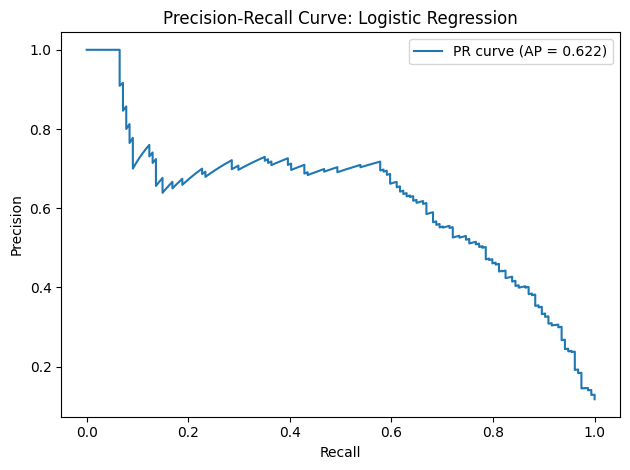

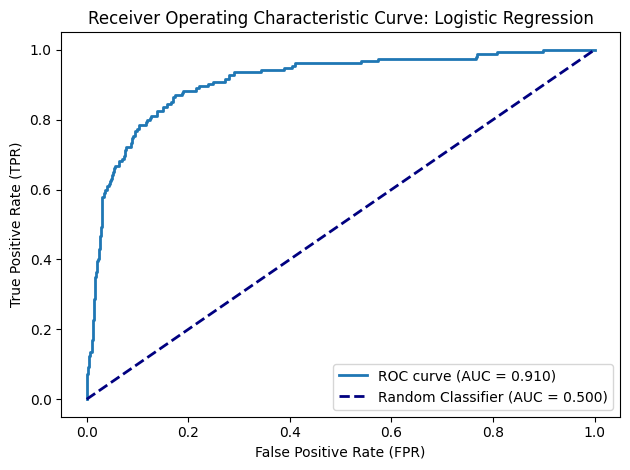

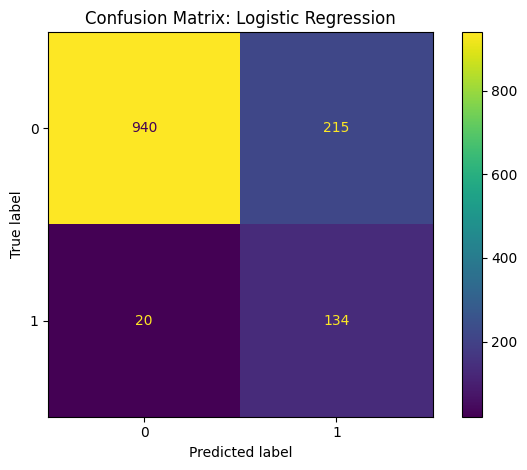


>>> Processing Model: Support Vector Machine <<<

Best parameters: SVC(C=10, class_weight='balanced', probability=True)

Results:
AP=0.686, ROC-AUC=0.898, F1=0.629, MCC=0.581
Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.91      0.94      1155
         1.0       0.54      0.76      0.63       154

    accuracy                           0.89      1309
   macro avg       0.75      0.84      0.78      1309
weighted avg       0.92      0.89      0.90      1309



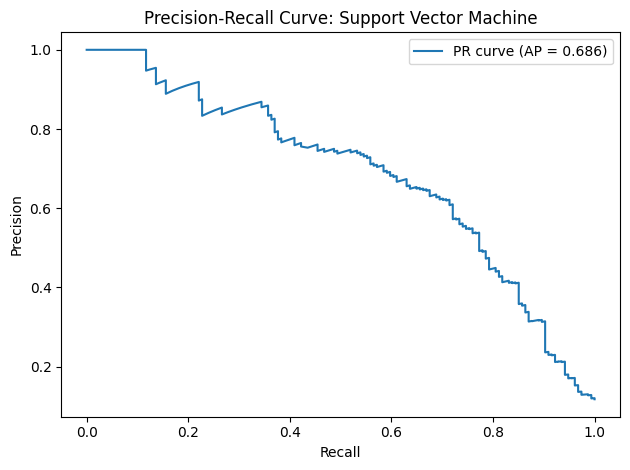

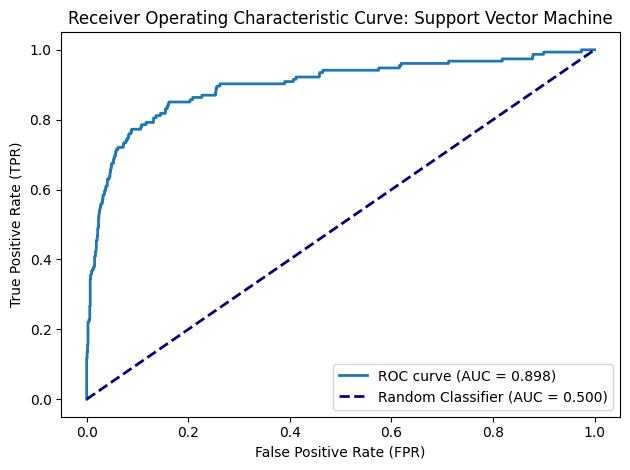

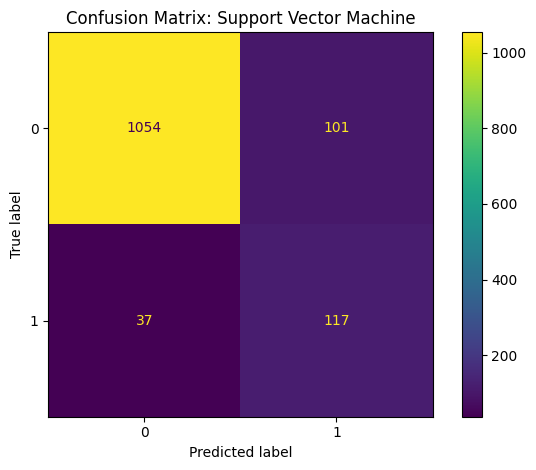


>>> Processing Model: Random Forest <<<

Best parameters: RandomForestClassifier(class_weight='balanced', n_estimators=300)

Results:
AP=0.678, ROC-AUC=0.916, F1=0.449, MCC=0.464
Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.99      0.95      1155
         1.0       0.80      0.31      0.45       154

    accuracy                           0.91      1309
   macro avg       0.86      0.65      0.70      1309
weighted avg       0.90      0.91      0.89      1309



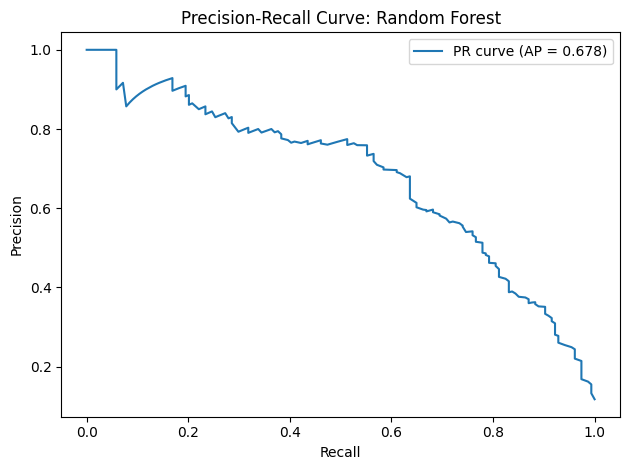

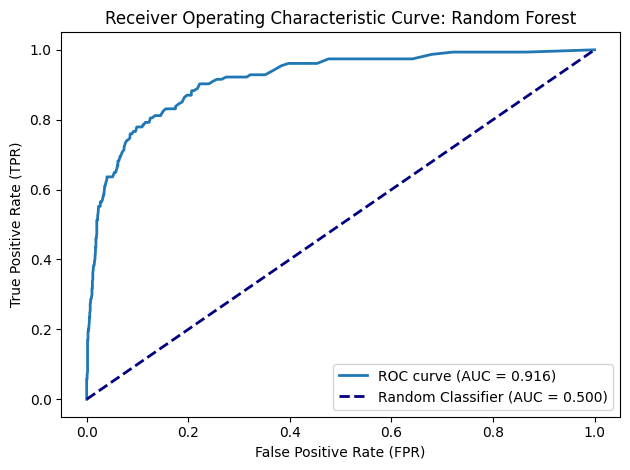

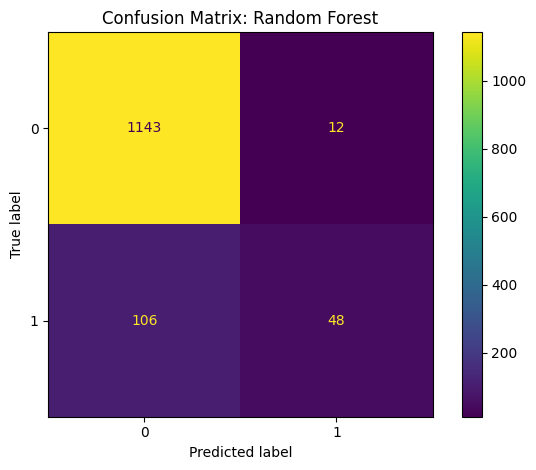

In [68]:
# training using molecular descriptors

desc = model_training(models, "mol_descriptors", desc_X_train_selected, desc_X_test_selected, y_train, y_test)

In [69]:
# results of molecular descriptors

print(desc)

desc.to_csv("results/mol_descriptors.csv")

                    Model    PR-AUC   ROC-AUC        F1       MCC
1  Support Vector Machine  0.686423  0.898088  0.629032  0.581394
2           Random Forest  0.678219  0.916408  0.448598  0.464186
0     Logistic Regression  0.622133  0.910317  0.532803  0.498366


### **4.2 Morgan Fingerprints Training**


>>> Processing Model: Logistic Regression <<<

Best parameters: LogisticRegression(C=0.1, class_weight='balanced', max_iter=2000, penalty='l2',
                   solver='liblinear')

Results:
AP=0.645, ROC-AUC=0.907, F1=0.592, MCC=0.549
Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.88      0.92      1155
         1.0       0.47      0.81      0.59       154

    accuracy                           0.87      1309
   macro avg       0.72      0.84      0.76      1309
weighted avg       0.91      0.87      0.88      1309



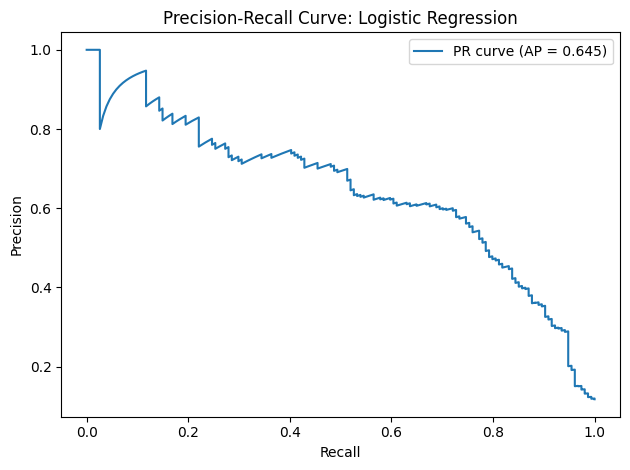

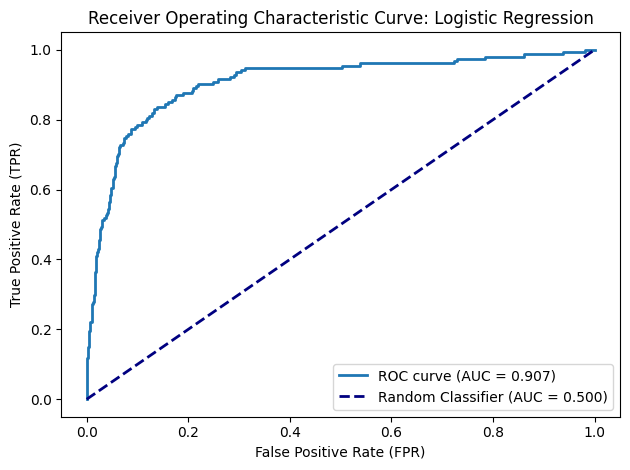

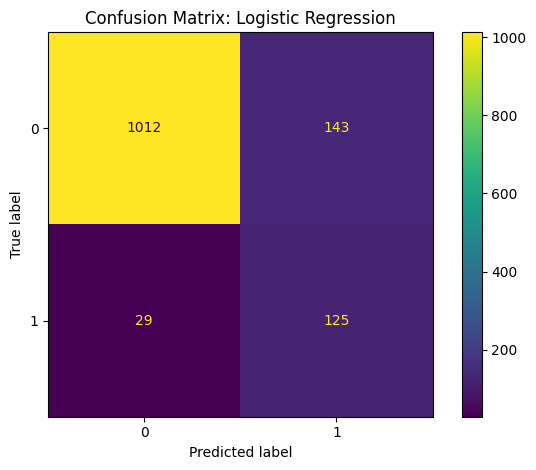


>>> Processing Model: Support Vector Machine <<<

Best parameters: SVC(C=1, class_weight='balanced', kernel='poly', probability=True)

Results:
AP=0.684, ROC-AUC=0.912, F1=0.633, MCC=0.586
Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.96      0.95      1155
         1.0       0.65      0.62      0.63       154

    accuracy                           0.92      1309
   macro avg       0.80      0.79      0.79      1309
weighted avg       0.91      0.92      0.91      1309



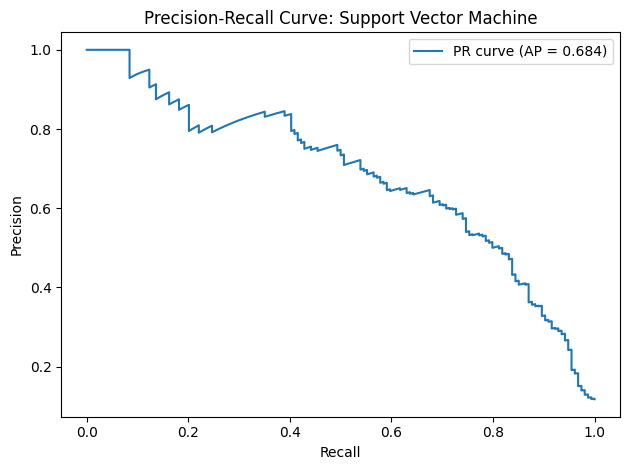

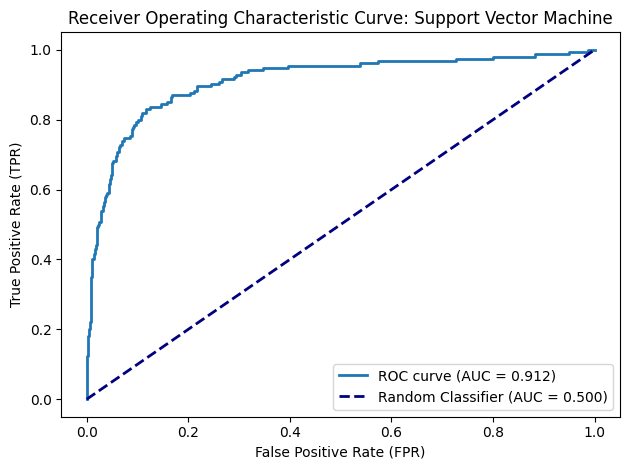

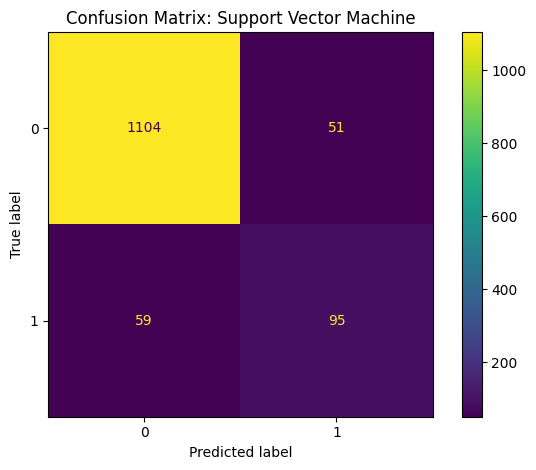


>>> Processing Model: Random Forest <<<

Best parameters: RandomForestClassifier(class_weight='balanced', n_estimators=300)

Results:
AP=0.663, ROC-AUC=0.919, F1=0.500, MCC=0.503
Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.99      0.95      1155
         1.0       0.80      0.36      0.50       154

    accuracy                           0.91      1309
   macro avg       0.86      0.68      0.73      1309
weighted avg       0.91      0.91      0.90      1309



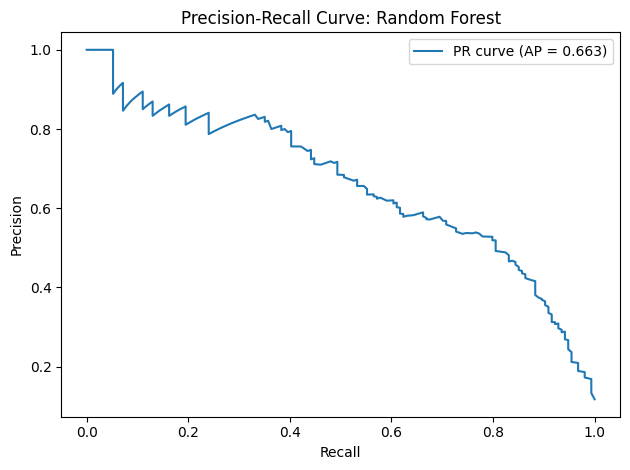

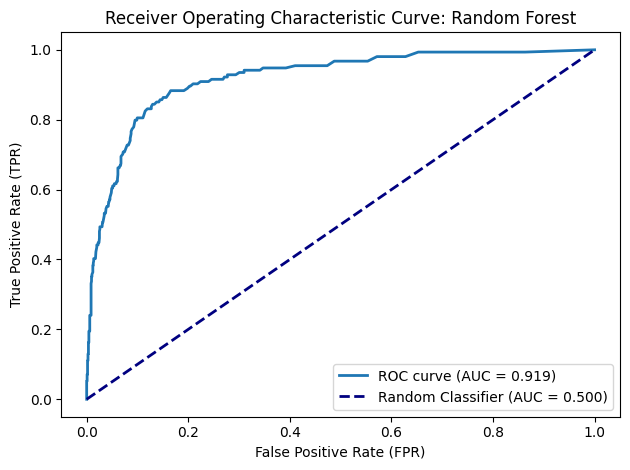

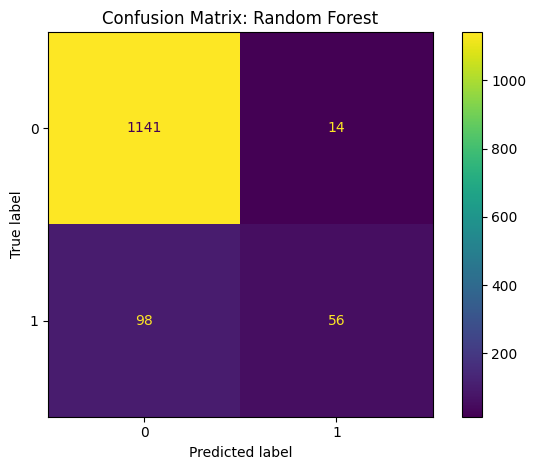

In [70]:
# training using morgan fingerprints

fp = model_training(models, "morgan_fp", fp_X_train, fp_X_test, y_train, y_test)

In [71]:
# results of morgan fingerprints

print(fp)

fp.to_csv("results/morgan_fp.csv")

                    Model    PR-AUC   ROC-AUC        F1       MCC
1  Support Vector Machine  0.683671  0.911767  0.633333  0.586183
2           Random Forest  0.663106  0.918589  0.500000  0.503397
0     Logistic Regression  0.645112  0.907202  0.592417  0.549251


### **4.3 Combined Features Training**


>>> Processing Model: Logistic Regression <<<

Best parameters: LogisticRegression(C=0.1, class_weight='balanced', max_iter=2000, penalty='l2',
                   solver='liblinear')

Results:
AP=0.704, ROC-AUC=0.920, F1=0.624, MCC=0.588
Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      0.88      0.93      1155
         1.0       0.49      0.85      0.62       154

    accuracy                           0.88      1309
   macro avg       0.74      0.87      0.78      1309
weighted avg       0.92      0.88      0.89      1309



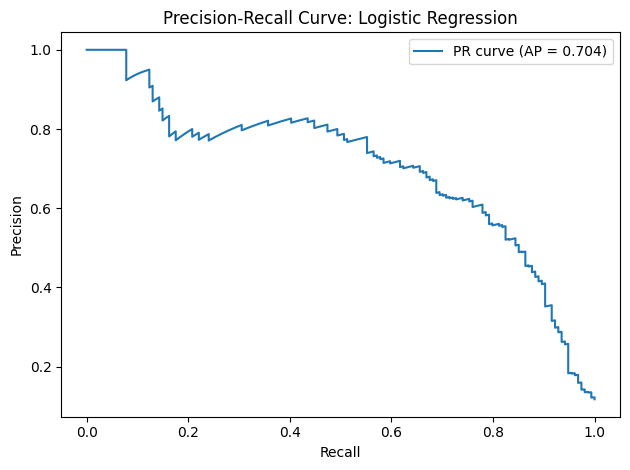

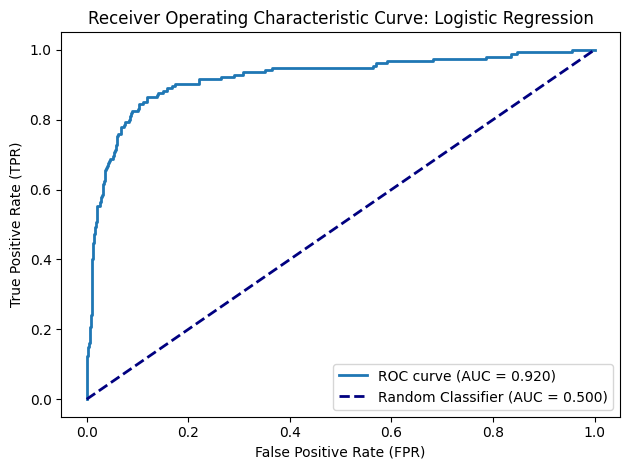

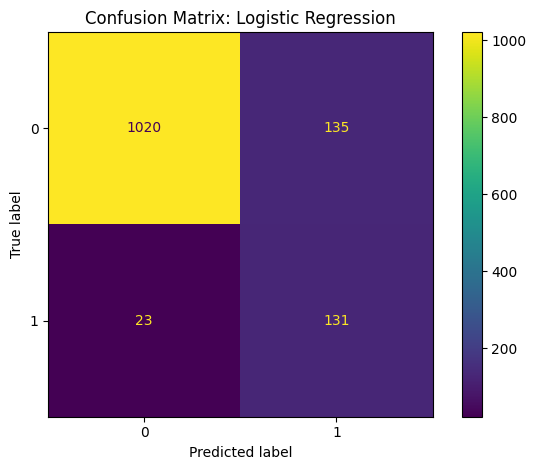


>>> Processing Model: Support Vector Machine <<<

Best parameters: SVC(C=10, class_weight='balanced', probability=True)

Results:
AP=0.723, ROC-AUC=0.911, F1=0.667, MCC=0.622
Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.95      0.95      1155
         1.0       0.66      0.68      0.67       154

    accuracy                           0.92      1309
   macro avg       0.81      0.81      0.81      1309
weighted avg       0.92      0.92      0.92      1309



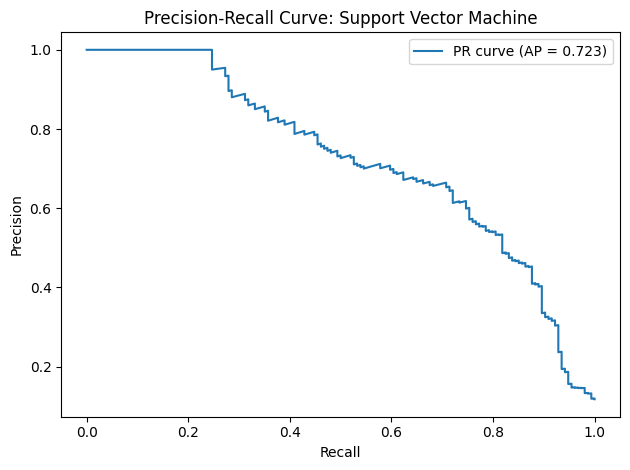

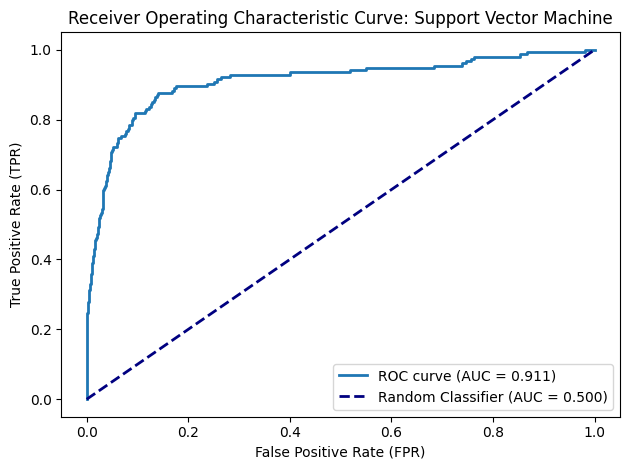

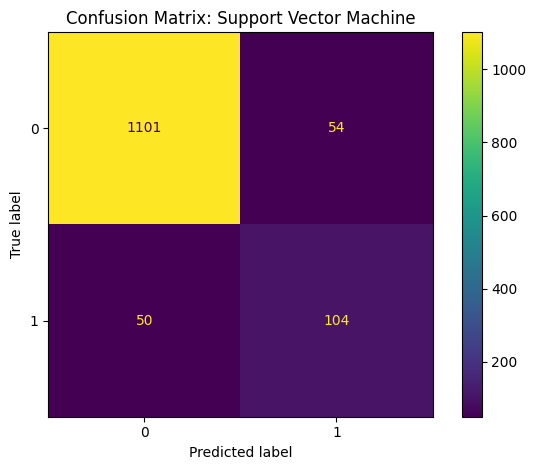


>>> Processing Model: Random Forest <<<

Best parameters: RandomForestClassifier(class_weight='balanced', n_estimators=300)

Results:
AP=0.707, ROC-AUC=0.926, F1=0.534, MCC=0.550
Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.99      0.96      1155
         1.0       0.88      0.38      0.53       154

    accuracy                           0.92      1309
   macro avg       0.90      0.69      0.75      1309
weighted avg       0.92      0.92      0.91      1309



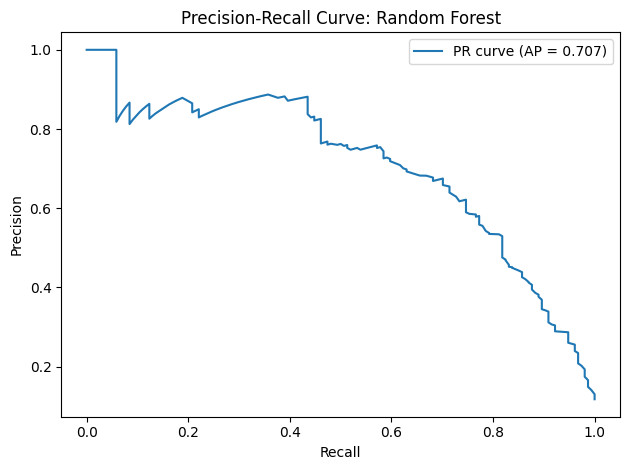

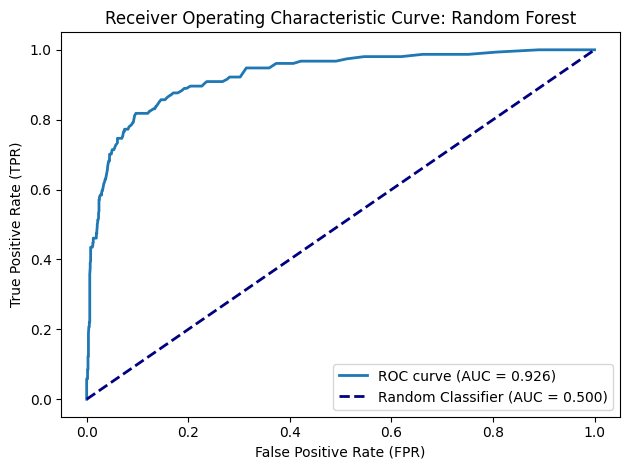

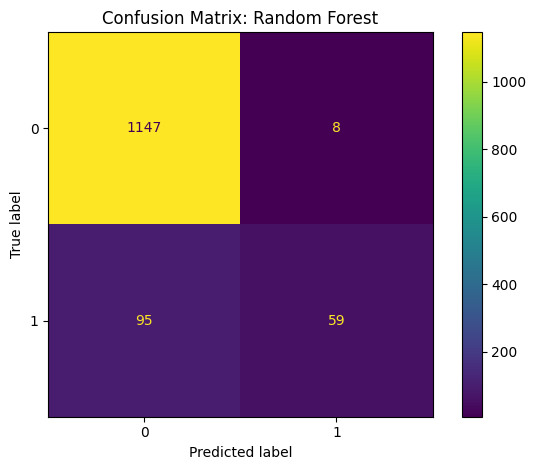

In [72]:
# training using mixed features

mixed = model_training(models, "mixed", X_train, X_test, y_train, y_test)

In [73]:
# results of mixed features

print(mixed)

mixed.to_csv("results/mixed.csv")

                    Model    PR-AUC   ROC-AUC        F1       MCC
1  Support Vector Machine  0.723236  0.911036  0.666667  0.621641
2           Random Forest  0.706894  0.926446  0.533937  0.549998
0     Logistic Regression  0.703787  0.920076  0.623810  0.587525


## **5. Final Results**

In [74]:
# print final results

df = pd.concat(
    [desc.assign(Run="desc"), fp.assign(Run="fp"), mixed.assign(Run="mixed")],
    ignore_index=True
)

df["Model"] = df["Model"] + " " + df["Run"]
df = df.sort_values(by="PR-AUC", ascending=False).drop(columns="Run")

print(df)

df.to_csv("results/best_models.csv")

                          Model    PR-AUC   ROC-AUC        F1       MCC
6  Support Vector Machine mixed  0.723236  0.911036  0.666667  0.621641
7           Random Forest mixed  0.706894  0.926446  0.533937  0.549998
8     Logistic Regression mixed  0.703787  0.920076  0.623810  0.587525
0   Support Vector Machine desc  0.686423  0.898088  0.629032  0.581394
3     Support Vector Machine fp  0.683671  0.911767  0.633333  0.586183
1            Random Forest desc  0.678219  0.916408  0.448598  0.464186
4              Random Forest fp  0.663106  0.918589  0.500000  0.503397
5        Logistic Regression fp  0.645112  0.907202  0.592417  0.549251
2      Logistic Regression desc  0.622133  0.910317  0.532803  0.498366
